# Day 13: Batch Normalization & Learning Rate Scheduling

> **Goal:** Understand Batch Normalization (what it does, why it helps), and learn to use LR schedulers to train faster and better.

---

## Why BatchNorm?

As data flows through many layers, the distribution of activations can shift — a phenomenon called **internal covariate shift**. This makes training unstable and slow.

**Batch Normalization** normalizes each layer's input across the mini-batch:

$$\hat{x} = \frac{x - \mu_{\text{batch}}}{\sqrt{\sigma^2_{\text{batch}} + \epsilon}}$$

Then applies learnable scale (γ) and shift (β):

$$y = \gamma \hat{x} + \beta$$

**Benefits:**
- Faster convergence
- Higher learning rates are OK
- Mild regularization effect
- Reduces sensitivity to initialization

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

Device: mps


### Data Setup

We'll use the full MNIST training set (48K train, 12K val) for these experiments so we can clearly see the effect of BatchNorm and LR scheduling on convergence speed.

In [4]:
# Data setup (reusing from previous days)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

full_train = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_data  = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_size = int(0.8 * len(full_train))
val_size = len(full_train) - train_size
train_data, val_data = random_split(full_train, [train_size, val_size],
                                     generator=torch.Generator().manual_seed(42))

BATCH_SIZE = 128
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)}")
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)})")

Train: 48000, Val: 12000, Test: 10000
Train batches: 375, Val batches: 94)


---
## 1. BatchNorm in Practice

PyTorch provides:
- `nn.BatchNorm1d(num_features)` — for 1D data (after Linear layers)
- `nn.BatchNorm2d(num_channels)` — for 2D data (after Conv2d layers)

**Placement:** Usually goes **between** the linear/conv layer and the activation:

```
Linear → BatchNorm → ReLU
```

In [5]:
# Model WITHOUT BatchNorm
class MLP_NoBN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )
    def forward(self, x):
        return self.net(x)


# Model WITH BatchNorm
class MLP_BN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256),
            nn.BatchNorm1d(256),   # ← normalize 256-dim activations
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),   # ← normalize 128-dim activations
            nn.ReLU(),
            nn.Linear(128, 10),
        )
    def forward(self, x):
        return self.net(x)


print("Model WITHOUT BatchNorm:")
print(MLP_NoBN())
print(f"\nModel WITH BatchNorm:")
print(MLP_BN())

Model WITHOUT BatchNorm:
MLP_NoBN(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)

Model WITH BatchNorm:
MLP_BN(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Linear(in_features=128, out_features=10, bias=True)
  )
)


### Training Helpers & Experiment

Next, we define our training loop and run both models with identical settings (same seed, optimizer, learning rate) so the **only difference** is BatchNorm. This controlled comparison lets us isolate BatchNorm's effect.

In [6]:
# Training helpers
def train_one_epoch(model, loader, loss_fn, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * labels.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        total_loss += loss.item() * labels.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total

In [7]:
# Train both models and compare
def run_experiment(ModelClass, name, epochs=15, lr=1e-3):
    torch.manual_seed(42)
    model = ModelClass().to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    for epoch in range(epochs):
        tl, ta = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
        vl, va = evaluate(model, val_loader, loss_fn, device)
        history["train_loss"].append(tl)
        history["val_loss"].append(vl)
        history["train_acc"].append(ta)
        history["val_acc"].append(va)
    print(f"{name:20s} | Final val acc: {va:.2%}")
    return history

h_nobn = run_experiment(MLP_NoBN, "Without BatchNorm")
h_bn   = run_experiment(MLP_BN,   "With BatchNorm")

Without BatchNorm    | Final val acc: 97.66%
With BatchNorm       | Final val acc: 98.12%


### Results Comparison

The plots below compare validation loss and accuracy for models with and without BatchNorm. You should see that BatchNorm leads to **faster convergence** (lower loss at earlier epochs) and often a slightly higher final accuracy. The improvement comes from stabilizing the distribution of activations flowing through the network.

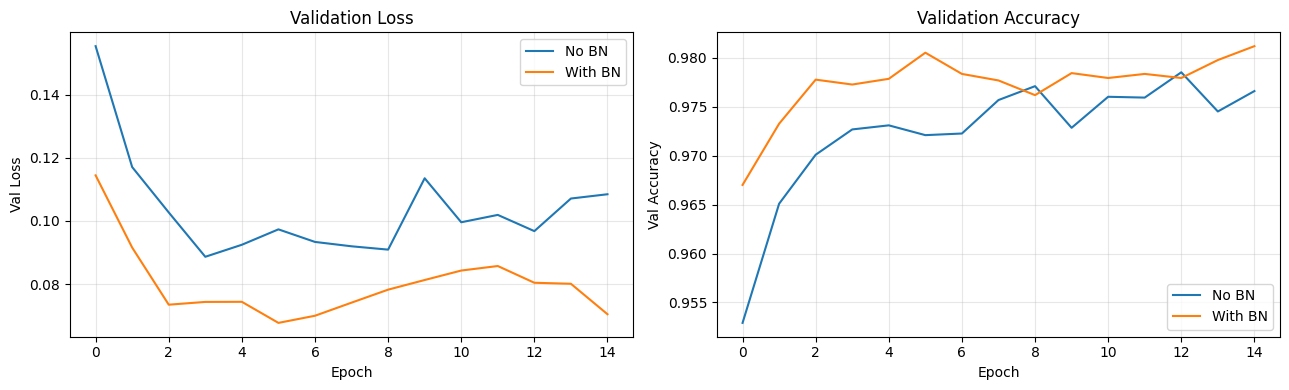

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
for h, label in [(h_nobn, "No BN"), (h_bn, "With BN")]:
    ax1.plot(h["val_loss"], label=label)
    ax2.plot(h["val_acc"], label=label)
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Val Loss"); ax1.set_title("Validation Loss")
ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Val Accuracy"); ax2.set_title("Validation Accuracy")
ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Train vs Eval behavior of BatchNorm

| Mode | What happens |
|---|---|
| `model.train()` | Uses batch statistics (mean, var of current batch) |
| `model.eval()` | Uses **running** statistics (accumulated during training) |

This is why you **must** call `model.eval()` before inference!

---
## 2. Learning Rate Scheduling

### The problem with fixed learning rates

- **Too high:** Training is unstable, loss oscillates or diverges
- **Too low:** Training is slow, may get stuck in poor local minima
- **Ideal:** Start high for fast progress, then decrease for fine-tuning

**LR Schedulers** automatically adjust the learning rate during training.

### Common Schedulers

| Scheduler | Strategy |
|---|---|
| `StepLR` | Multiply LR by `gamma` every `step_size` epochs |
| `ExponentialLR` | Multiply LR by `gamma` every epoch |
| `CosineAnnealingLR` | Follow a cosine curve (smooth decay → warm restart) |
| `ReduceLROnPlateau` | Reduce when a metric stops improving |

/var/folders/w5/2bk4yy9n0jqc4g52g07kjbnc0000gn/T/ipykernel_12187/4286592432.py:9: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


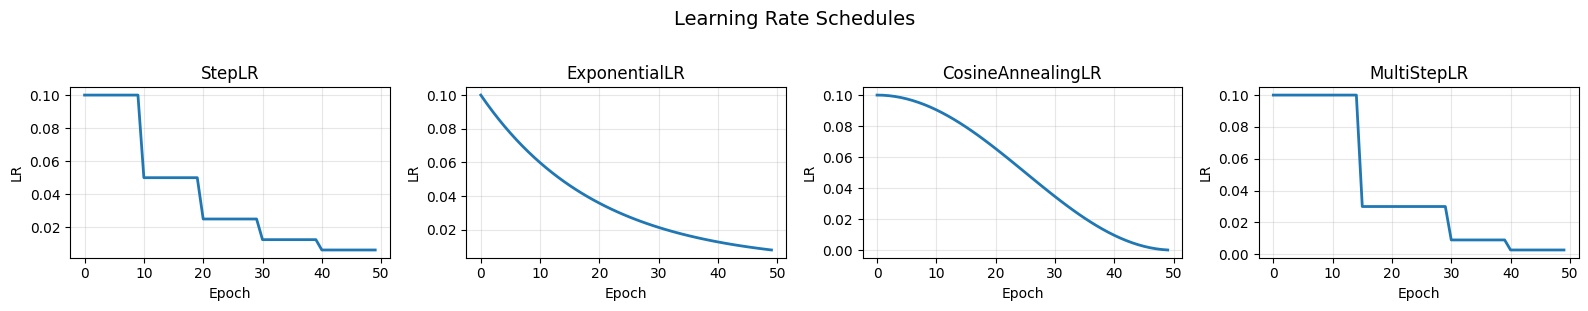

In [9]:
# Visualize different schedules
def get_lr_schedule(scheduler_class, epochs=50, lr=0.1, **kwargs):
    model = nn.Linear(10, 1)
    optimizer = optim.SGD(model.parameters(), lr=lr)
    scheduler = scheduler_class(optimizer, **kwargs)
    lrs = []
    for _ in range(epochs):
        lrs.append(optimizer.param_groups[0]["lr"])
        scheduler.step()
    return lrs

fig, axes = plt.subplots(1, 4, figsize=(16, 3))

schedules = [
    ("StepLR", optim.lr_scheduler.StepLR, {"step_size": 10, "gamma": 0.5}),
    ("ExponentialLR", optim.lr_scheduler.ExponentialLR, {"gamma": 0.95}),
    ("CosineAnnealingLR", optim.lr_scheduler.CosineAnnealingLR, {"T_max": 50}),
    ("MultiStepLR", optim.lr_scheduler.MultiStepLR, {"milestones": [15, 30, 40], "gamma": 0.3}),
]

for ax, (name, cls, kwargs) in zip(axes, schedules):
    lrs = get_lr_schedule(cls, epochs=50, lr=0.1, **kwargs)
    ax.plot(lrs, linewidth=2)
    ax.set_title(name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("LR")
    ax.grid(True, alpha=0.3)

plt.suptitle("Learning Rate Schedules", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 3. Training with a Scheduler

In [10]:
def train_with_scheduler(scheduler_name, scheduler_class, scheduler_kwargs, epochs=20):
    torch.manual_seed(42)
    model = MLP_BN().to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9)  # Start with high LR
    scheduler = scheduler_class(optimizer, **scheduler_kwargs)

    history = {"val_acc": [], "lr": []}
    for epoch in range(epochs):
        tl, ta = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
        vl, va = evaluate(model, val_loader, loss_fn, device)
        history["val_acc"].append(va)
        history["lr"].append(optimizer.param_groups[0]["lr"])
        scheduler.step()  # ← Update LR

    print(f"{scheduler_name:20s} | Final val acc: {va:.2%}")
    return history

# Compare: no scheduler vs CosineAnnealing
h_const = train_with_scheduler("Constant LR",
    optim.lr_scheduler.StepLR, {"step_size": 999, "gamma": 1.0}, epochs=20)
h_cosine = train_with_scheduler("CosineAnnealing",
    optim.lr_scheduler.CosineAnnealingLR, {"T_max": 20}, epochs=20)
h_step = train_with_scheduler("StepLR",
    optim.lr_scheduler.StepLR, {"step_size": 7, "gamma": 0.3}, epochs=20)

Constant LR          | Final val acc: 98.11%
CosineAnnealing      | Final val acc: 98.28%
StepLR               | Final val acc: 98.27%


### Scheduler Comparison Results

The left plot shows how each LR schedule affects validation accuracy, and the right plot shows the actual learning rate over time. Notice how **CosineAnnealing** provides a smooth decay that typically gives the best results — it starts with fast learning and gradually fine-tunes as the rate approaches zero.

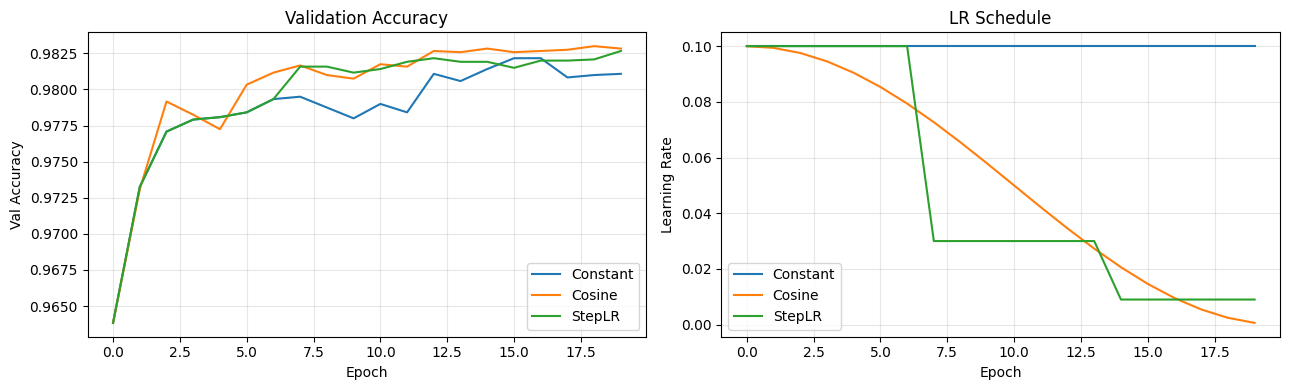

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
for h, name in [(h_const, "Constant"), (h_cosine, "Cosine"), (h_step, "StepLR")]:
    ax1.plot(h["val_acc"], label=name)
    ax2.plot(h["lr"], label=name)
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Val Accuracy"); ax1.set_title("Validation Accuracy")
ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Learning Rate"); ax2.set_title("LR Schedule")
ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 🧪 Exercises

### Exercise 1: BatchNorm with higher learning rate
Try lr=0.1 for both MLP_NoBN and MLP_BN. Which one can handle it? Why?

### Exercise 2: ReduceLROnPlateau
Implement training with `ReduceLROnPlateau(optimizer, patience=3, factor=0.5)`. Note: this scheduler needs `scheduler.step(val_loss)`.

### Exercise 3: Warmup + Cosine decay
Implement a custom schedule: linearly increase LR from 0 to 0.01 over 5 epochs, then cosine decay. Plot the LR curve.

### Exercise 4: Inspect BatchNorm parameters
After training, print the learned γ (weight) and β (bias) of each BatchNorm layer. Also print the running mean and variance.

In [ ]:
# Exercise 1: Your code here

In [ ]:
# Exercise 2: Your code here

In [ ]:
# Exercise 3: Your code here

In [ ]:
# Exercise 4: Your code here

---
## 📝 Key Takeaways

| Concept | Summary |
|---|---|
| **BatchNorm** | Normalizes activations per mini-batch; speeds up training; mild regularization |
| **BN placement** | After Linear/Conv, before activation: `Linear → BN → ReLU` |
| **train() vs eval()** | BN uses batch stats in train, running stats in eval |
| **LR Schedulers** | Automatically adjust LR during training |
| **CosineAnnealingLR** | Smooth decay, often works very well |
| **StepLR / MultiStepLR** | Drop LR at specific epochs |
| **scheduler.step()** | Call once per epoch (or step, depending on scheduler) |

**Tomorrow:** We'll refactor everything into a clean, reusable training pipeline with checkpointing and reproducibility.